<a href="https://colab.research.google.com/github/d-monkey-CG/DFW-Residential-Housing-Price-Predictor/blob/main/DFW_Home_Price_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis of the (preliminary) completed DFW Home Price Dataset**

Note: Only the three most populous and/or fastest growing counties were included in this dataset (Dallas County, Tarrant County, Collin County). The data available for all three is from 2021 - 2025.

In [14]:
#To import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
#To load the dataset from google drive
data = pd.read_parquet('/content/drive/MyDrive/Python Data Science Honors Project/DFW_CBINC.parquet')

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508395 entries, 0 to 11508394
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   TaxYear               int64  
 1   YearBuilt             int64  
 2   ActualArea            int64  
 3   LandValue             int64  
 4   has_pool              bool   
 5   IndicatedEquityValue  int64  
 6   situsbldgnum          float64
 7   situsstreetprefix     object 
 8   situsstreetsuffix     object 
 9   situsstreetname       object 
 10  situszip              int64  
 11  county                object 
 12  Median_H_Inc          float64
dtypes: bool(1), float64(2), int64(6), object(4)
memory usage: 1.0+ GB


In [20]:
#To drop rows where the property is most likely a mobile home
#Mobile homes are appraised differently B/C they are depreciating assets

data = data[~((data['LandValue'] == 0) & (data['IndicatedEquityValue'] < 50000))]

In [21]:
#Function To create a visual for each year where all counties have available data
#This visualization is meant to be easy to understand not STATS heavy

def lp_eda(year, data_load):
    df = data_load[data_load['TaxYear'] == year]

    #To create a visualization for the distibution of home appraisal values by year
    bins = [0, 200_000, 300_000, 400_000, 500_000, 750_000, 1_500_000, np.inf]
    labels = [
        "Under $200k",
        "$200k–$300k",
        "$300k–$400k",
        "$400k–$500k",
        "$500k–$750k",
        "$750k-$1.5M",
        "$1.5M+"
    ]

    price_groups = pd.cut(df["IndicatedEquityValue"],
                          bins=bins,
                          labels=labels,
                          include_lowest=True
                          )
    counts = price_groups.value_counts().reindex(labels)

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title(f"Home Value Ranges {year}")
    plt.xlabel("Home value range")
    plt.ylabel("Number of homes")
    plt.show()



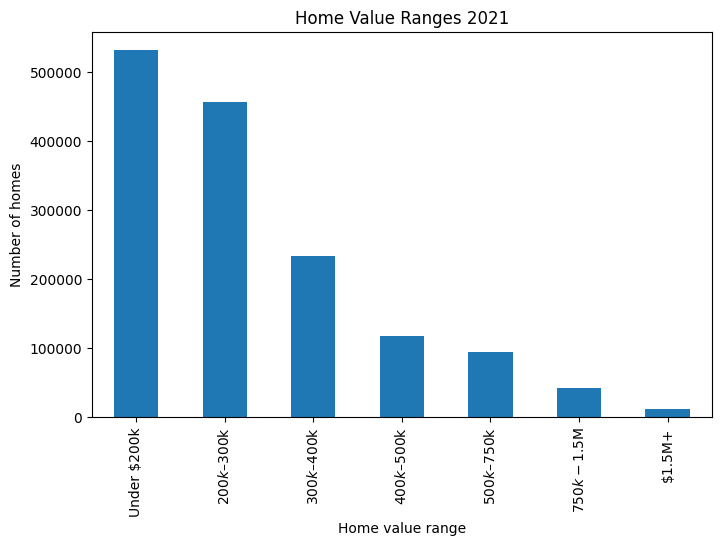

In [22]:
lp_eda(2021, data)

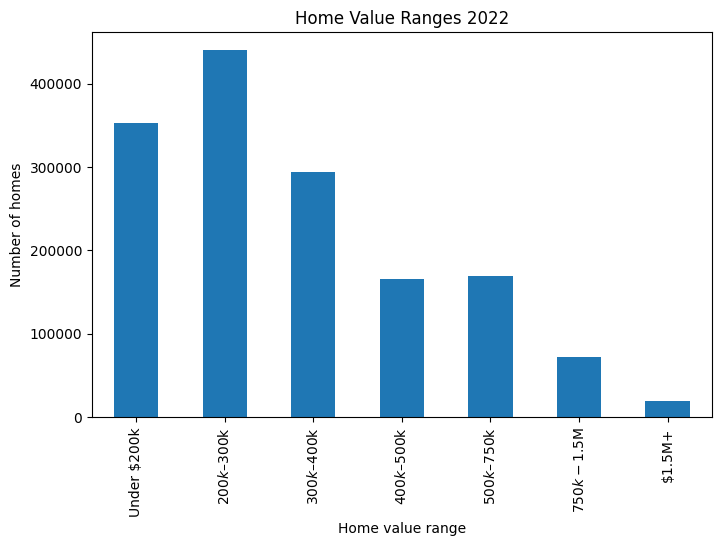

In [23]:
lp_eda(2022, data)

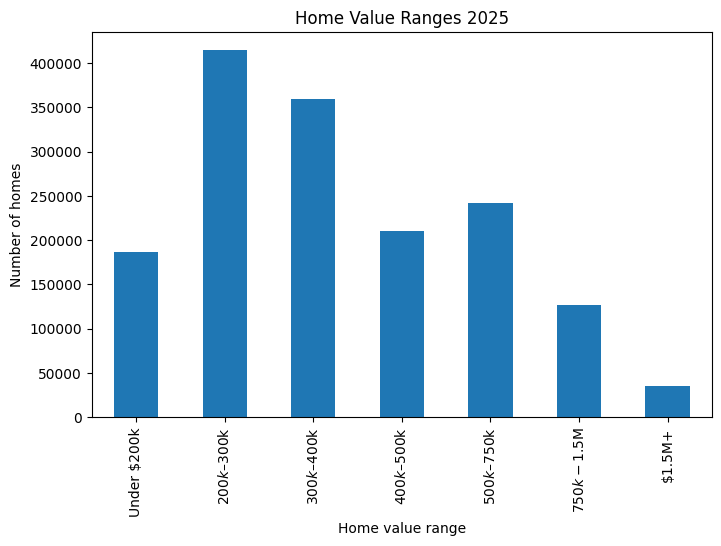

In [24]:
lp_eda(2025, data)

In [25]:
#To create dataframes for 2021 and 2025 to see the Appraisal changes over a 5 yr period
#This portion is more STATS oriented

df_2021 = data[data['TaxYear'] == 2021]
val_2021 = df_2021['IndicatedEquityValue']

df_2025 = data[data['TaxYear'] == 2025]
val_2025 = df_2025['IndicatedEquityValue']

In [29]:
#To calulcate the skewness and curtosis of residential home values
#We should expect to see a really high number for skewness as home values tend
#to have a long right tail

from scipy.stats import skew, kurtosis

shape_stats_21 = {
    "skewness": skew(val_2021),
    "kurtosis": kurtosis(val_2021),
}

print('FY 2021')
pd.Series(shape_stats_21)

FY 2021


,0
skewness,20.965922
kurtosis,1634.336108


In [30]:
shape_stats_25 = {
    "skewness": skew(val_2025),
    "kurtosis": kurtosis(val_2025),
}

print('FY 2025')
pd.Series(shape_stats_25)

FY 2025


,0
skewness,15.001660
kurtosis,643.623623


Based on these results we can conclude that the **average** home appraisal value is not a useful metric, the **median** value is going to be the more accurate metric.

However, it is important to note that both skewness and kurtosis decreased significantly over the 5 year period.

The other thing to keep in mind is that the 2021 visualization looks nothing like a typical bell curve, but the shape of the 2025 visual does have a more normal bell curve shape.

In theory this is a good thing as it results in a better distribution, but in practice it means that there are significantly less homes that are valued at under 200K and significantly more homes in the 400K to 750K range.

These figures don't represent exact numbers, but are in fact good estimates for the area.

In [31]:
val_2021.median()

240720.0

In [32]:
val_2025.median()

345475.0

In [34]:
#To calculate the %change in median appraisal values from 2021 - 2025

change_per = val_2025.median() / val_2021.median()

print(f"The median home appraisal value difference from 2021 - 2025 is {change_per - 1}")

The median home appraisal value difference from 2021 - 2025 is 0.43517364572947814
